In [1]:
%matplotlib inline

In [2]:
import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
    make_scorer
)
from sklearn.model_selection import KFold

In [5]:
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [6]:
RANDOM_STATE = 42
USE_GPU = True
N_COMPONENTS = 20

In [7]:
# ---- 0. Paths ----
DATA_DIR = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset"
TRAIN_FILE = f"{DATA_DIR}/ML_train.csv"
TEST_FILE = f"{DATA_DIR}/ML_test.csv"
BERT_FILE = r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\bert_embeddings.csv"

In [8]:
# ---- 1. Load data + fixed PCA (N=20) ----
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
bert_raw = pd.read_csv(BERT_FILE)

In [9]:
TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

In [10]:
train_ids = set(train_df["id"])
feature_cols = [c for c in bert_raw.columns if c != "id"]
train_mask = bert_raw["id"].isin(train_ids)

In [11]:
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(bert_raw.loc[train_mask, feature_cols])
reduced_all = pca.transform(bert_raw[feature_cols])
reduced_cols = [f"bert_pca_{i}" for i in range(N_COMPONENTS)]
reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
reduced_df.insert(0, "id", bert_raw["id"].values)

In [12]:
merged_train = train_df.merge(reduced_df, on="id", how="left")
merged_test = test_df.merge(reduced_df, on="id", how="left")

In [13]:
X_train = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
X_test = merged_test.drop(columns=DROP_FROM_X, errors="ignore")
y_train = merged_train[TARGET_LOG].copy()
y_test = merged_test[TARGET_LOG].copy()
actual_usd = merged_test[TARGET_RAW].to_numpy()

In [14]:
assert list(X_train.columns) == list(X_test.columns)
print(f"Train rows: {len(X_train)} | Feature count: {X_train.shape[1]}")

Train rows: 16000 | Feature count: 97


In [15]:
# ---- 2. Evaluation helper ----
def evaluate_model(y_true_log, pred_log, actual_usd):
    pred_usd = np.expm1(pred_log)
    pred_usd = np.clip(pred_usd, a_min=0, a_max=None)

    mae_log = mean_absolute_error(y_true_log, pred_log)
    mse_log = mean_squared_error(y_true_log, pred_log)
    rmse_log = np.sqrt(mse_log)
    r2_log = r2_score(y_true_log, pred_log)

    mae_usd = mean_absolute_error(actual_usd, pred_usd)
    mse_usd = mean_squared_error(actual_usd, pred_usd)
    rmse_usd = np.sqrt(mse_usd)
    r2_usd = r2_score(actual_usd, pred_usd)

    rmsle = np.sqrt(mean_squared_log_error(actual_usd, pred_usd))

    return {
        "MAE_log": mae_log, "MSE_log": mse_log, "RMSE_log": rmse_log, "R2_log": r2_log,
        "MAE_USD": mae_usd, "MSE_USD": mse_usd, "RMSE_USD": rmse_usd, "R2_USD": r2_usd,
        "RMSLE": rmsle
    }

In [16]:
# ---- 3. BayesSearchCV setup (search space fixed, only CV folds change) ----
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [17]:
rmse_scorer = make_scorer(rmse, greater_is_better=False)
N_ITER_BAYES = 4

In [18]:
xgb_bayes_space = {
    "n_estimators":     Integer(200, 500),
    "learning_rate":    Real(0.01, 0.1, prior="log-uniform"),
    "max_depth":        Integer(4, 9),
    "min_child_weight": Integer(1, 7),
    "subsample":        Real(0.7, 1.0),
    "colsample_bytree": Real(0.7, 1.0),
    "reg_alpha":        Real(1e-3, 0.5, prior="log-uniform"),
    "reg_lambda":       Real(0.5, 3.0),
}

In [19]:
def make_search(n_splits):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    base_estimator = XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", device="cuda" if USE_GPU else "cpu",
        random_state=RANDOM_STATE,
    )
    return BayesSearchCV(
        estimator=base_estimator, search_spaces=xgb_bayes_space, n_iter=N_ITER_BAYES,
        scoring=rmse_scorer, cv=cv, n_jobs=1,
        random_state=RANDOM_STATE, verbose=0, refit=True,
    )

In [20]:
# ---- 4. Ablation loop over fold counts ----
FOLD_COUNTS = [3, 5, 10]
approx_val_size = len(X_train) // np.array(FOLD_COUNTS)

In [21]:
ablation_results = []
best_params_by_fold = {}

In [22]:
for n_splits, val_size in zip(FOLD_COUNTS, approx_val_size):
    print(f"\n{'='*70}")
    print(f"CV FOLDS = {n_splits}  (approx {val_size} rows/fold)")
    print(f"{'='*70}")

    search = make_search(n_splits)
    start_time = time.time()
    search.fit(X_train, y_train)
    tuning_time = time.time() - start_time

    best_model = search.best_estimator_
    pred_log = best_model.predict(X_test)

    metrics = evaluate_model(y_test, pred_log, actual_usd)
    metrics["CV_Folds"] = n_splits
    metrics["Approx_Val_Size"] = val_size
    metrics["Best_CV_RMSE_log"] = -search.best_score_
    metrics["Tuning_Time_Seconds"] = tuning_time

    ablation_results.append(metrics)
    best_params_by_fold[str(n_splits)] = dict(search.best_params_)

    print(f"Best params: {dict(search.best_params_)}")
    print(f"RMSLE={metrics['RMSLE']:.4f} | R2_log={metrics['R2_log']:.4f} | "
          f"R2_USD={metrics['R2_USD']:.4f} | time={tuning_time:.1f}s")


CV FOLDS = 3  (approx 5333 rows/fold)
Best params: {'colsample_bytree': 0.9512165066659852, 'learning_rate': 0.07643904937766527, 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 459, 'reg_alpha': 0.0014729254229045347, 'reg_lambda': 0.845771345696438, 'subsample': 0.8060762192885254}
RMSLE=1.5065 | R2_log=0.7578 | R2_USD=0.1769 | time=32.3s

CV FOLDS = 5  (approx 3200 rows/fold)
Best params: {'colsample_bytree': 0.9512165066659852, 'learning_rate': 0.07643904937766527, 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 459, 'reg_alpha': 0.0014729254229045347, 'reg_lambda': 0.845771345696438, 'subsample': 0.8060762192885254}
RMSLE=1.5065 | R2_log=0.7578 | R2_USD=0.1769 | time=72.9s

CV FOLDS = 10  (approx 1600 rows/fold)
Best params: {'colsample_bytree': 0.9512165066659852, 'learning_rate': 0.07643904937766527, 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 459, 'reg_alpha': 0.0014729254229045347, 'reg_lambda': 0.845771345696438, 'subsample': 0.8060762192885254}
RMSL

In [23]:
# ---- 5. Results table ----
results_df = pd.DataFrame(ablation_results)
results_df = results_df[[
    "CV_Folds", "Approx_Val_Size",
    "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD",
    "RMSLE", "Best_CV_RMSE_log", "Tuning_Time_Seconds"
]]
print("\n" + "="*70)
print("ABLATION RESULTS: CV fold sensitivity (3 vs 5 vs 10)")
print("="*70)
print(results_df)


ABLATION RESULTS: CV fold sensitivity (3 vs 5 vs 10)
   CV_Folds  Approx_Val_Size   MAE_log   MSE_log  RMSE_log    R2_log  \
0         3             5333  1.115845  2.275488  1.508472  0.757791   
1         5             3200  1.115845  2.275488  1.508472  0.757791   
2        10             1600  1.115845  2.275488  1.508472  0.757791   

       MAE_USD       MSE_USD      RMSE_USD    R2_USD     RMSLE  \
0  14587.04437  9.713670e+09  98557.950385  0.176912  1.506474   
1  14587.04437  9.713670e+09  98557.950385  0.176912  1.506474   
2  14587.04437  9.713670e+09  98557.950385  0.176912  1.506474   

   Best_CV_RMSE_log  Tuning_Time_Seconds  
0          1.535839            32.329852  
1          1.512840            72.900876  
2          1.492507           130.251842  


In [24]:
results_df.to_csv("cv_fold_sensitivity_results.csv", index=False)
with open("cv_fold_sensitivity_best_params.json", "w") as f:
    json.dump(best_params_by_fold, f, indent=2, default=str)

In [25]:
print("\nSaved: cv_fold_sensitivity_results.csv")
print("Saved: cv_fold_sensitivity_best_params.json")


Saved: cv_fold_sensitivity_results.csv
Saved: cv_fold_sensitivity_best_params.json


In [26]:
# ---- 6. Check if hyperparameter choices diverge across fold counts ----
params_df = pd.DataFrame(best_params_by_fold).T
params_df.index.name = "CV_Folds"
print("\nBest hyperparameters by fold count:")
print(params_df)


Best hyperparameters by fold count:
          colsample_bytree  learning_rate  max_depth  min_child_weight  \
CV_Folds                                                                 
3                 0.951217       0.076439        6.0               7.0   
5                 0.951217       0.076439        6.0               7.0   
10                0.951217       0.076439        6.0               7.0   

          n_estimators  reg_alpha  reg_lambda  subsample  
CV_Folds                                                  
3                459.0   0.001473    0.845771   0.806076  
5                459.0   0.001473    0.845771   0.806076  
10               459.0   0.001473    0.845771   0.806076  


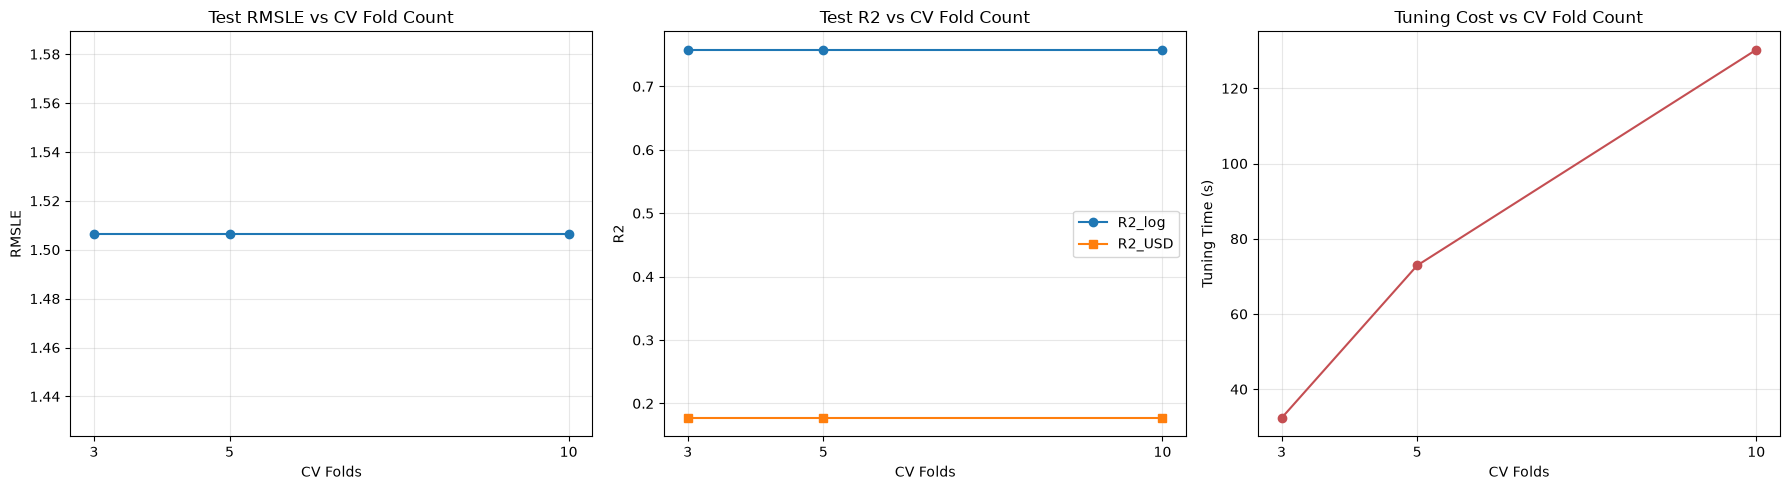

Saved: cv_fold_sensitivity_plot.png


In [27]:
# ---- 7. Plot (single cell) ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(results_df["CV_Folds"], results_df["RMSLE"], marker="o")
axes[0].set_xlabel("CV Folds")
axes[0].set_ylabel("RMSLE")
axes[0].set_title("Test RMSLE vs CV Fold Count")
axes[0].set_xticks(FOLD_COUNTS)
axes[0].grid(True, alpha=0.3)
axes[1].plot(results_df["CV_Folds"], results_df["R2_log"], marker="o", label="R2_log")
axes[1].plot(results_df["CV_Folds"], results_df["R2_USD"], marker="s", label="R2_USD")
axes[1].set_xlabel("CV Folds")
axes[1].set_ylabel("R2")
axes[1].set_title("Test R2 vs CV Fold Count")
axes[1].set_xticks(FOLD_COUNTS)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].plot(results_df["CV_Folds"], results_df["Tuning_Time_Seconds"], marker="o", color="#C44E52")
axes[2].set_xlabel("CV Folds")
axes[2].set_ylabel("Tuning Time (s)")
axes[2].set_title("Tuning Cost vs CV Fold Count")
axes[2].set_xticks(FOLD_COUNTS)
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cv_fold_sensitivity_plot.png", dpi=150)
plt.show()
print("Saved: cv_fold_sensitivity_plot.png")